In [1]:
"""
SHAP Analysis — Standalone
"""
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
from scipy.sparse import load_npz

import warnings
warnings.filterwarnings('ignore')

In [2]:
# CONFIG
TOP_N = 50
SHAP_SUBSAMPLE = 500        # set to None to use full test set (ram hungry)
RANDOM_STATE = 42

rng = np.random.RandomState(RANDOM_STATE)

In [3]:
# LOAD SAVED ARTIFACTS
print("Loading saved artifacts...")

with open("rf_last_fold_estimator.pkl", "rb") as f:
    rf_last = pickle.load(f)
print(f"  RF estimator: {rf_last.n_estimators} trees, max_depth={rf_last.max_depth}")

X_test_sparse = load_npz("shap_X_test.npz")
y_test = np.load("shap_y_test.npy")
feature_cols = np.load("shap_feature_cols.npy", allow_pickle=True).tolist()

print(f"  X_test: {X_test_sparse.shape}")
print(f"  y_test: {len(y_test)} (pos={y_test.sum()}, neg={len(y_test)-y_test.sum()})")
print(f"  Features: {len(feature_cols)}")

Loading saved artifacts...
  RF estimator: 856 trees, max_depth=23
  X_test: (45188, 6707)
  y_test: 45188 (pos=15, neg=45173)
  Features: 6707


In [4]:
# SUBSAMPLE TEST SET (optional but recommended)
if SHAP_SUBSAMPLE is not None and SHAP_SUBSAMPLE < X_test_sparse.shape[0]:
    print(f"\nSubsampling {SHAP_SUBSAMPLE} patients for SHAP...")

    # stratified subsample so we keep some positives in the mix
    pos_idx = np.where(y_test == 1)[0]
    neg_idx = np.where(y_test == 0)[0]

    # keep all positives if fewer than half the subsample, otherwise proportional
    n_pos_sample = min(len(pos_idx), SHAP_SUBSAMPLE // 2)
    n_neg_sample = SHAP_SUBSAMPLE - n_pos_sample

    sampled_pos = rng.choice(pos_idx, size=n_pos_sample, replace=False)
    sampled_neg = rng.choice(neg_idx, size=n_neg_sample, replace=False)
    shap_idx = np.concatenate([sampled_pos, sampled_neg])
    rng.shuffle(shap_idx)

    X_shap = X_test_sparse[shap_idx].toarray().astype(np.float64)
    y_shap = y_test[shap_idx]
    print(f"  SHAP subset: {X_shap.shape} (pos={y_shap.sum()}, neg={len(y_shap)-y_shap.sum()})")
else:
    print("\nUsing full test set for SHAP (hope you have ram, choom)...")
    X_shap = X_test_sparse.toarray().astype(np.float64)
    y_shap = y_test

del X_test_sparse
import gc; gc.collect()


Subsampling 500 patients for SHAP...
  SHAP subset: (500, 6707) (pos=15, neg=485)


77

In [5]:
# SHAP VALUES
print("\nComputing SHAP values...")

rf_explainer = shap.TreeExplainer(
    rf_last,
    feature_perturbation="interventional"
)
shap_values = rf_explainer.shap_values(X_shap, check_additivity=False)

print("type(shap_values):", type(shap_values))

if isinstance(shap_values, list):
    print("shapes:", [sv.shape for sv in shap_values])
    sv_to_plot = shap_values[1]

elif isinstance(shap_values, np.ndarray):
    print("ndarray shape:", shap_values.shape)
    n_feat = X_shap.shape[1]

    if shap_values.ndim == 2:
        sv_to_plot = shap_values
    elif shap_values.ndim == 3:
        if shap_values.shape[2] == n_feat:
            sv_to_plot = shap_values[:, 1, :]
        elif shap_values.shape[1] == n_feat:
            sv_to_plot = shap_values[:, :, 1]
        elif shap_values.shape[0] == n_feat:
            sv_to_plot = shap_values[:, :, 1].T
        else:
            raise ValueError(f"can't map 3D shap shape {shap_values.shape} to features={n_feat}")
    else:
        raise ValueError(f"unexpected shap ndim: {shap_values.ndim}")
else:
    raise TypeError(f"unexpected shap_values type: {type(shap_values)}")

# trim bias column if present
if sv_to_plot.shape[1] == X_shap.shape[1] + 1:
    print("trimming bias column")
    sv_to_plot = sv_to_plot[:, :-1]

print("final sv_to_plot.shape:", sv_to_plot.shape)
print("X_shap.shape:          ", X_shap.shape)
assert sv_to_plot.shape == X_shap.shape, "shapes still mismatched!"


Computing SHAP values...
type(shap_values): <class 'numpy.ndarray'>
ndarray shape: (500, 6707, 2)
final sv_to_plot.shape: (500, 6707)
X_shap.shape:           (500, 6707)



Generating SHAP summary plot...


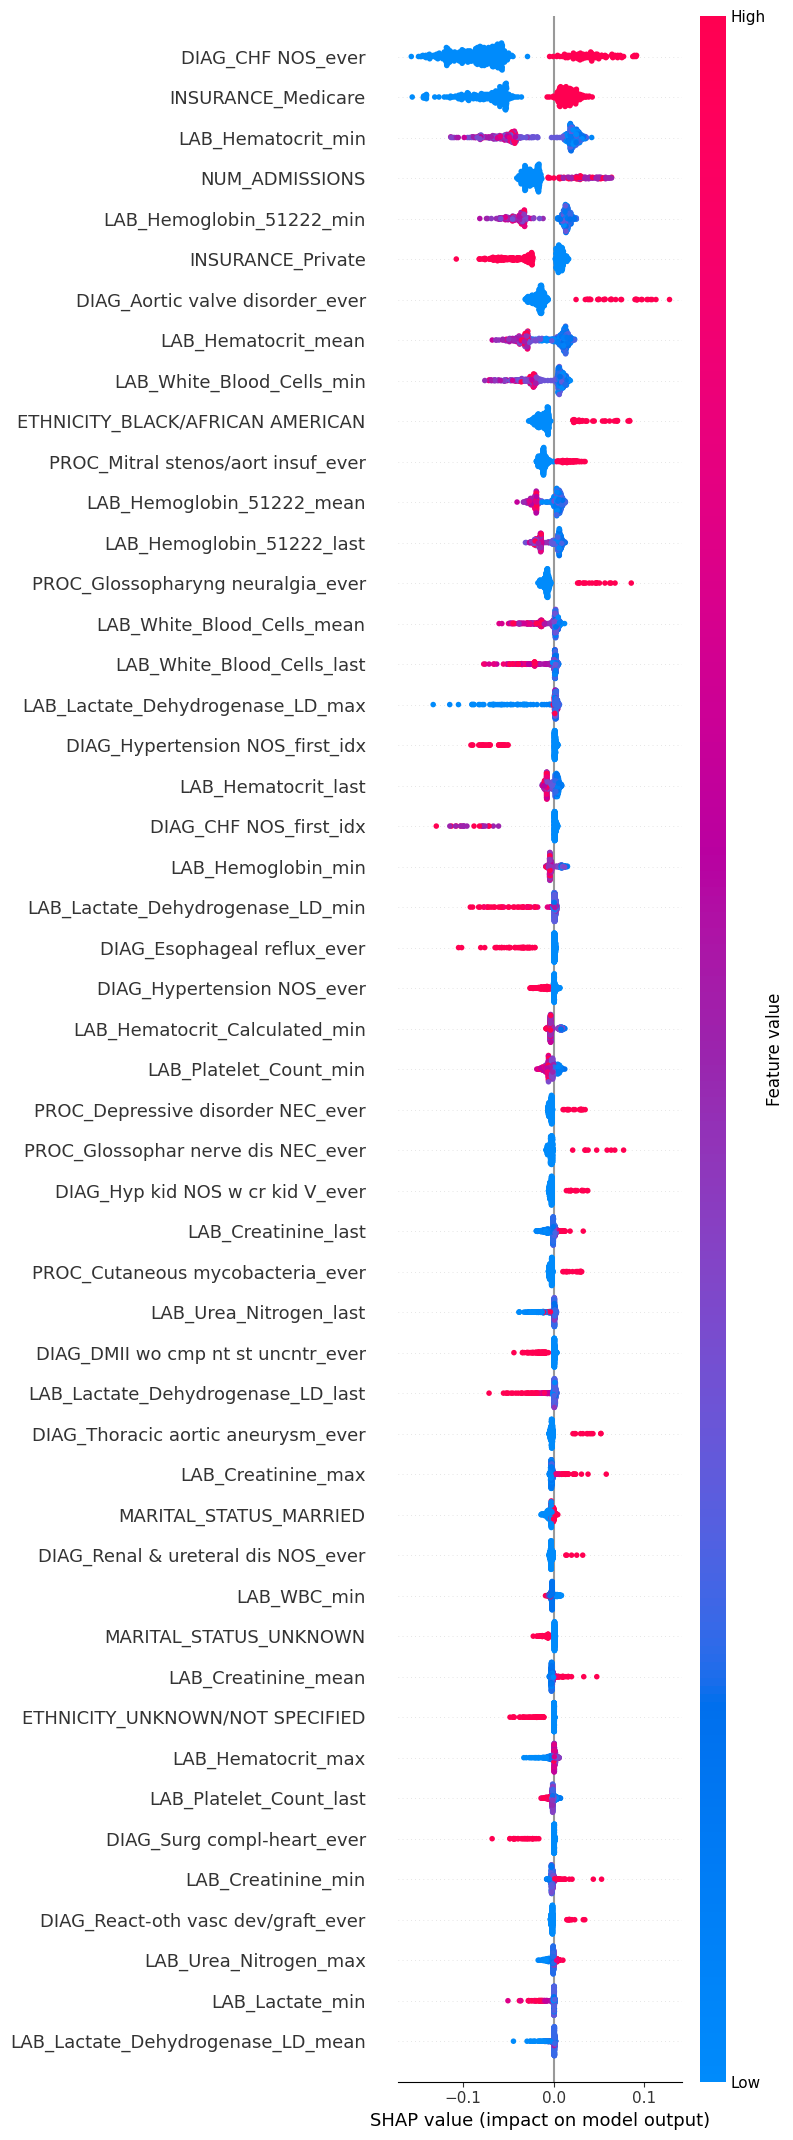

Saved: RF_Tuned_SHAP.png


In [6]:
# SUMMARY PLOT (dot)
print("\nGenerating SHAP summary plot...")

shap.summary_plot(
    sv_to_plot,
    X_shap,
    feature_names=feature_cols,
    max_display=TOP_N,
    show=False,
    plot_type="dot"
)
plt.tight_layout()
plt.savefig(r"RF_Tuned_SHAP.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RF_Tuned_SHAP.png")

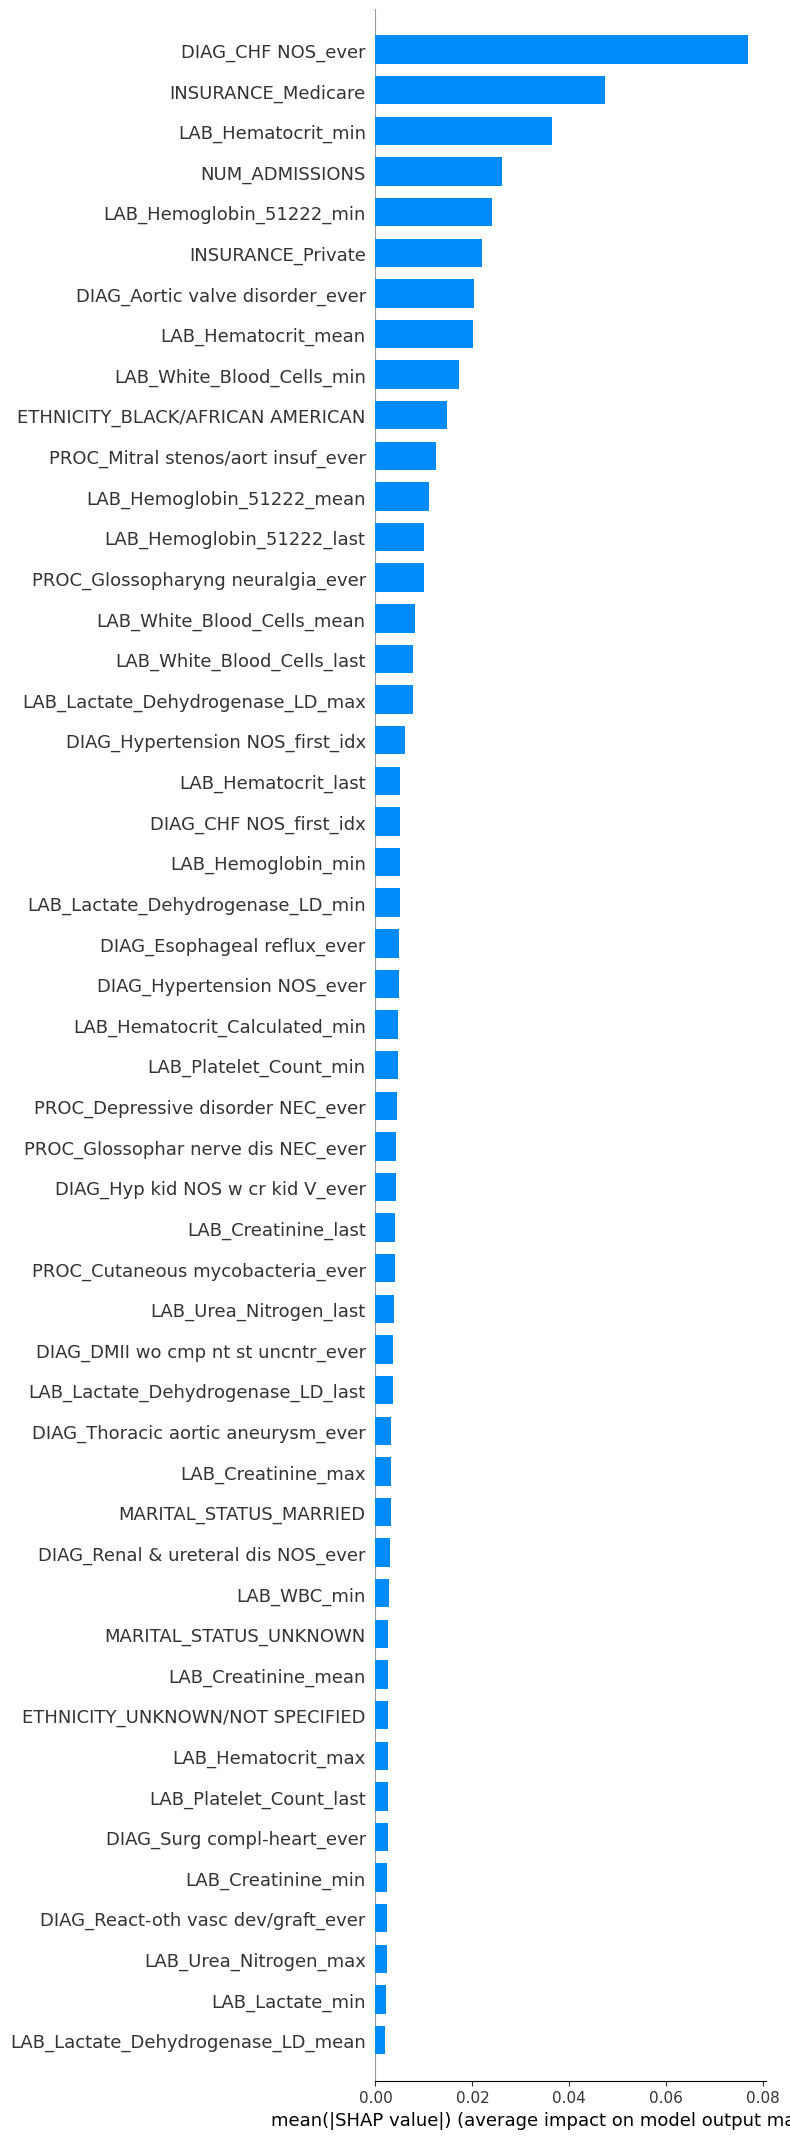

Saved: RF_Tuned_SHAP_bar.png


In [7]:
# =============================================================
# BAR PLOT (mean |SHAP|)
# =============================================================
shap.summary_plot(
    sv_to_plot,
    X_shap,
    feature_names=feature_cols,
    max_display=TOP_N,
    show=False,
    plot_type="bar"
)
plt.tight_layout()
plt.savefig(r"RF_Tuned_SHAP_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RF_Tuned_SHAP_bar.png")